<a href="https://colab.research.google.com/github/SarikMarik/Week_7/blob/main/KNN_NumPy_vs_ScikitLearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KNN Algorithm using NumPy and Scikit-learn

Code KNN from scratch with NumPy • Compare with Scikit-learn • Visualizations • K Selection (Elbow Method) • Exercises (Marked)

---
## 1. Introduction

**K-Nearest Neighbors (KNN)** is a simple, instance-based (lazy) learning algorithm. Unlike eager learners that build a model during training, KNN defers all computation until prediction time: given a new point, it finds the *k* training examples closest to it (by some distance, usually Euclidean) and assigns the majority class among those neighbors. No explicit model is learned—the "model" is the entire training set.

Because KNN is **distance-based**, the choice of distance metric (Euclidean, Manhattan, Minkowski) and, crucially, the value of **k** strongly affect performance. Too small *k* leads to overfitting and noise sensitivity; too large *k* can underfit and blur class boundaries. Thus **k selection** (e.g., via elbow method or cross-validation) is essential.

In this lab we **implement KNN from scratch using only NumPy** on a simple 2D synthetic dataset, then solve the **same problem with Scikit-learn** and compare accuracy, parameters, and visualizations (decision boundaries, accuracy vs *k*). We also cover **k selection methods** and end with **marked exercises** on a 3-class dataset, sklearn comparison, and a real-world dataset.

---
## 2. Part A: Simple Example – KNN from Scratch with NumPy

We generate a simple 2D synthetic dataset with 50 samples and 2 classes using `np.random`, implement a full KNN using only NumPy (Euclidean distance + majority voting), then predict on a test set and compute accuracy.

### 2.1 Imports and Setup

In [ ]:
%matplotlib inline

# part I
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# part II
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# for visualization
# Dark-theme friendly style for plots
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 10

### 2.2 Generate Simple 2D Synthetic Dataset (50 samples, 2 classes)

In [ ]:
# Fix seed for reproducibility
np.random.seed(42)

# Class 0: centered around (2, 2)
n_per_class = 25
X0 = np.random.randn(n_per_class, 2) + np.array([2, 2])
y0 = np.zeros(n_per_class, dtype=int)

# Class 1: centered around (3.5, 3.5)
X1 = np.random.randn(n_per_class, 2) + np.array([3.5, 3.5])
y1 = np.ones(n_per_class, dtype=int)

# Combine into single dataset
X = np.vstack([X0, X1])
y = np.hstack([y0, y1])

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0], "| Test samples:", X_test.shape[0])
print("Class distribution (train):", np.bincount(y_train))

Training samples: 40 | Test samples: 10
Class distribution (train): [22 18]


### 2.2.1 Visualize Generated Dataset

Before normalization, we plot the raw 2D data colored by class. This helps confirm the two clusters and the train/test split.

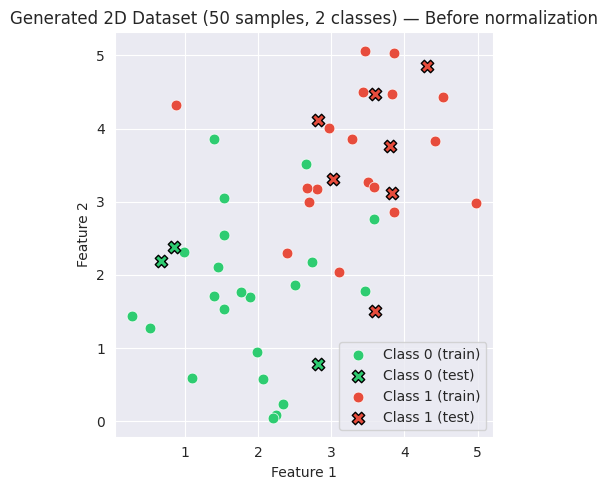

In [ ]:
# Scatter plot: full dataset colored by class (circles = train, crosses = test for clarity)
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2ecc71', '#e74c3c']
for cls in [0, 1]:
    train_mask = (y_train == cls)
    test_mask = (y_test == cls)
    ax.scatter(X_train[train_mask, 0], X_train[train_mask, 1], c=colors[cls], label=f'Class {cls} (train)',
               s=60, edgecolors='white', linewidths=0.5, marker='o')
    ax.scatter(X_test[test_mask, 0], X_test[test_mask, 1], c=colors[cls], edgecolors='black', linewidths=1,
               s=80, marker='X', label=f'Class {cls} (test)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Generated 2D Dataset (50 samples, 2 classes) — Before normalization')
ax.legend(loc='best', ncol=1)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 2.2.2 Feature Normalization (Min-Max)

KNN is distance-based, so features on different scales can dominate. **Min-max normalization** scales each feature to [0, 1] using the **training set** min/max (to avoid data leakage). We then apply the same transformation to the test set.

In [ ]:
# Min-max normalization: fit on train, apply to train and test
X_min = X_train.min(axis=0)
X_max = X_train.max(axis=0)
X_range = X_max - X_min


X_train = (X_train - X_min) / X_range
X_test = (X_test - X_min) / X_range

# Update full X and y for later scatter/decision-boundary plots (same order: train then test)
X = np.vstack([X_train, X_test])
y = np.hstack([y_train, y_test])

print("Min-max normalization applied (fitted on training set).")
print("Feature 1 — min: {:.4f}, max: {:.4f} (on train)".format(X_min[0], X_max[0]))
print("Feature 2 — min: {:.4f}, max: {:.4f} (on train)".format(X_min[1], X_max[1]))
print("Train range after norm: [{:.4f}, {:.4f}]".format(X_train.min(), X_train.max()))

Min-max normalization applied (fitted on training set).
Feature 1 — min: 0.2751, max: 4.9779 (on train)
Feature 2 — min: 0.0403, max: 5.0646 (on train)
Train range after norm: [0.0000, 1.0000]


### 2.3 KNN Class from Scratch (NumPy only: Euclidean distance + majority voting)

In [ ]:
class KNN_NumPy:
    """K-Nearest Neighbors implemented from scratch using only NumPy."""

    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """Store training data (lazy learner: no model built)."""
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)
        return self

    def _euclidean_distances(self, X):
        """Compute Euclidean distance from each row of X to every row of X_train."""
        # (n_test, n_features) vs (n_train, n_features) -> (n_test, n_train)
        diff = X[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]  # broadcasting
        return np.sqrt(np.sum(diff ** 2, axis=2))

    def predict(self, X):
        """Predict class by majority vote among k nearest neighbors."""
        X = np.asarray(X)
        dists = self._euclidean_distances(X)  # (n_test, n_train)
        # Indices of k smallest distances per test point
        k_nearest_idx = np.argsort(dists, axis=1)[:, :self.k]  # (n_test, k)
        # Labels of those neighbors
        neighbor_labels = self.y_train[k_nearest_idx]  # (n_test, k)
        # Majority vote: most frequent label per row
        preds = np.array([np.bincount(row).argmax() for row in neighbor_labels])
        return preds

    def predict_single_with_neighbors(self, x):
        """Predict for one point and return prediction + indices of k nearest neighbors (for viz)."""
        x = np.atleast_2d(x)
        dists = self._euclidean_distances(x).ravel()
        k_nearest_idx = np.argsort(dists)[:self.k]
        neighbor_labels = self.y_train[k_nearest_idx]
        pred = np.bincount(neighbor_labels).argmax()
        return pred, k_nearest_idx

### 2.4 Train, Predict, and Compute Accuracy

In [ ]:
k_numpy = 5
knn_numpy = KNN_NumPy(k=k_numpy)
knn_numpy.fit(X_train, y_train)

y_pred_numpy = knn_numpy.predict(X_test)
acc_numpy = np.mean(y_pred_numpy == y_test)

print(f"NumPy KNN (k={k_numpy}) — Test Accuracy: {acc_numpy:.4f}")
print("Example predictions (first 10 test points):")
print("True:", y_test[:10])
print("Pred:", y_pred_numpy[:10])

NumPy KNN (k=5) — Test Accuracy: 0.9000
Example predictions (first 10 test points):
True: [0 1 1 1 0 1 1 1 1 0]
Pred: [0 0 1 1 0 1 1 1 1 0]


---
## 3. Part B: Same Problem with Scikit-learn

We use `sklearn.neighbors.KNeighborsClassifier` on the **exact same** train/test split and compare accuracy. Key parameters are explained below.

In [ ]:
knn_sklearn = KNeighborsClassifier(n_neighbors=k_numpy, weights='uniform', metric='euclidean', algorithm='auto')
knn_sklearn.fit(X_train, y_train)
y_pred_sklearn = knn_sklearn.predict(X_test)
acc_sklearn = accuracy_score(y_test, y_pred_sklearn)

print(f"Scikit-learn KNN (k={k_numpy}) — Test Accuracy: {acc_sklearn:.4f}")
print("\nSide-by-side comparison:")
print(f"  NumPy scratch:  {acc_numpy:.4f}")
print(f"  Scikit-learn:   {acc_sklearn:.4f}")

Scikit-learn KNN (k=5) — Test Accuracy: 0.9000

Side-by-side comparison:
  NumPy scratch:  0.9000
  Scikit-learn:   0.9000


### Important Parameters of KNeighborsClassifier

| Parameter | Description |
|-----------|-------------|
| **n_neighbors** | Number of neighbors *k*. Larger *k* = smoother boundary, less overfitting. |
| **weights** | `'uniform'`: all k neighbors have equal vote. `'distance'`: closer neighbors have higher weight (inverse distance). |
| **metric** | Distance metric: `'euclidean'`, `'manhattan'`, `'minkowski'`, or callable. |
| **algorithm** | `'auto'` (chooses best), `'ball_tree'`, `'kd_tree'`, `'brute'`. Brute is O(n) per query; tree methods speed up in higher dimensions. |

---
## 4. Visualizations

We produce: (1) scatter plot of the dataset colored by class, (2) decision boundary for both NumPy and sklearn using meshgrid, (3) k nearest neighbors highlighted for one test point, (4) accuracy vs K plot (Elbow method).

### 4.1 Scatter Plot of Dataset (colored by class)

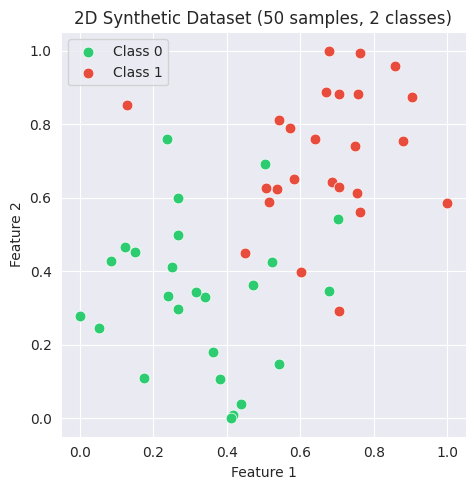

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2ecc71', '#e74c3c']  # Dark-theme friendly green and red
for cls in [0, 1]:
    mask = y == cls
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[cls], label=f'Class {cls}', s=60, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('2D Synthetic Dataset (50 samples, 2 classes)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 4.2 Decision Boundary (NumPy and Sklearn) using meshgrid

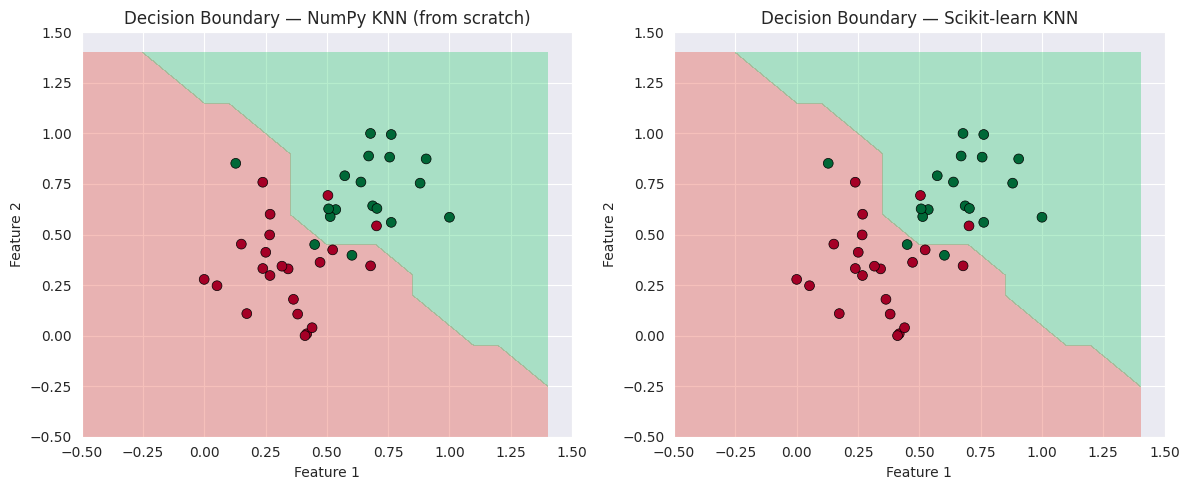

In [ ]:
def plot_decision_boundary(X, y, model, title, ax, mesh_step=0.1):
    """Plot decision boundary by predicting on a dense grid."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, mesh_step), np.arange(y_min, y_max, mesh_step))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, levels=[-0.5, 0.5, 1.5], colors=[ '#e74c3c', '#2ecc71'])
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn', edgecolors='black', linewidths=0.5, s=50)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(X_train, y_train, knn_numpy, 'Decision Boundary — NumPy KNN (from scratch)', ax1)
plot_decision_boundary(X_train, y_train, knn_sklearn, 'Decision Boundary — Scikit-learn KNN', ax2)
plt.tight_layout()
plt.show()

### 4.3 Highlight k Nearest Neighbors for One Test Point

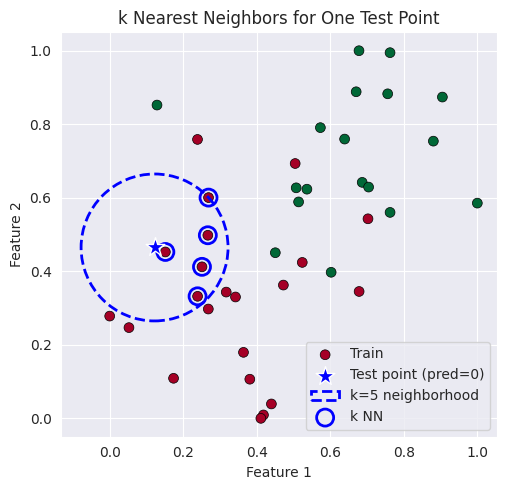

In [ ]:
# Pick first test point
test_point = X_test[0]
pred, neighbor_idx = knn_numpy.predict_single_with_neighbors(test_point)
neighbor_pts = X_train[neighbor_idx]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdYlGn', s=50, edgecolors='black', linewidths=0.5, label='Train')
ax.scatter(test_point[0], test_point[1], c='blue', s=200, marker='*', edgecolors='white', linewidths=1, label=f'Test point (pred={pred})', zorder=5)
# Circle around test point to show neighborhood
dists = np.sqrt(np.sum((X_train - test_point)**2, axis=1))
r = np.sort(dists)[k_numpy - 1]  # radius to include k-th neighbor
circle = plt.Circle(test_point, r, fill=False, color='blue', linestyle='--', linewidth=2, label=f'k={k_numpy} neighborhood')
ax.add_patch(circle)
ax.scatter(neighbor_pts[:, 0], neighbor_pts[:, 1], facecolors='none', edgecolors='blue', s=150, linewidths=2, label='k NN')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('k Nearest Neighbors for One Test Point')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### 4.4 Accuracy vs K (Elbow Method for choosing optimal K)

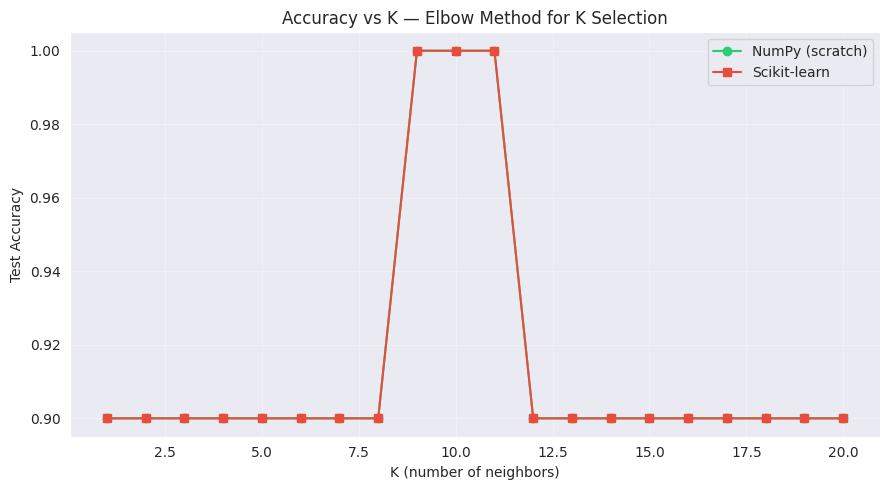

In [ ]:
k_range = range(1, 21)
accuracies_numpy = []
accuracies_sklearn = []

for k in k_range:
    knn_n = KNN_NumPy(k=k)
    knn_n.fit(X_train, y_train)
    acc_n = np.mean(knn_n.predict(X_test) == y_test)
    accuracies_numpy.append(acc_n)

    knn_s = KNeighborsClassifier(n_neighbors=k)
    knn_s.fit(X_train, y_train)
    acc_s = accuracy_score(y_test, knn_s.predict(X_test))
    accuracies_sklearn.append(acc_s)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, accuracies_numpy, 'o-', color='#2ecc71', label='NumPy (scratch)')
ax.plot(k_range, accuracies_sklearn, 's-', color='#e74c3c', label='Scikit-learn')
ax.set_xlabel('K (number of neighbors)')
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs K — Elbow Method for K Selection')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Comparison Table: NumPy vs Scikit-learn

| Criterion | NumPy (from scratch) | Scikit-learn |
|-----------|----------------------|-------------|
| **Speed** | Slower (no optimized indexing; O(n) per query) | Faster (optional ball_tree/kd_tree, optimized C) |
| **Ease** | More code, full control over distance and voting | Few lines, many options (weights, metrics, algorithm) |
| **Accuracy** | Same as sklearn with same k and Euclidean uniform weights | Same when parameters match; extra options (e.g. distance weights) can improve |
| **Use case** | Learning, custom metrics/voting | Production, quick experiments, tuning |

---
## 5. K Selection Methods

**Elbow Method:** Plot accuracy (or error) vs *k* and look for the "elbow" where gain in accuracy flattens. Avoid very small *k* (noisy) and very large *k* (underfitting).

**Cross-validation:** Use multiple train/validation splits to estimate performance for each *k* and pick the *k* with best average validation accuracy (or use `GridSearchCV`).

### 5.1 Elbow Method (already plotted above)

The plot in Section 4.4 is the elbow curve. Choose *k* where accuracy is high and stable.

### 5.2 Cross-Validation for Best K (loop and GridSearchCV)

In [ ]:
# Manual loop with cross_val_score
from sklearn.model_selection import cross_val_score

cv_scores = []
for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

best_k_loop = np.argmax(cv_scores) + 1
print(f"Best K (5-fold CV, manual loop): {best_k_loop} with mean CV accuracy {max(cv_scores):.4f}")

# GridSearchCV
param_grid = {'n_neighbors': list(range(1, 21))}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
print(f"Best K (GridSearchCV): {grid.best_params_['n_neighbors']} with CV score {grid.best_score_:.4f}")

Best K (5-fold CV, manual loop): 7 with mean CV accuracy 0.9000
Best K (GridSearchCV): 7 with CV score 0.9000


---
## 6. Lab Exercises (Total 100 marks)

Complete the following in the cells below. Marks are indicated for each part.

### Part 1 (50 marks) – More Complex Dataset with NumPy

**Dataset:** Prepared in the cells below: **X_train_ex1**, **X_test_ex1**, **y_train_ex1**, **y_test_ex1** (3-class, 2 features, raw). **X_ex1**, **y_ex1** are the full data for decision-boundary plots.

**Instructions:**  
- **Apply min-max normalization** (fit on train, transform train and test) before fitting KNN.
- Implement **full KNN from scratch** using only NumPy (distance function, majority voting, prediction). You can adapt the **KNN_NumPy** class from Part A to handle 3 classes.
- Compute **accuracy** and **confusion matrix** manually (e.g. using `np.unique` and loops to build the matrix).
- **Write your code in the cell below.**

### Dataset for Part 1 & Part 2 (3-class, ready to use)

Run the cell below once. It generates a 3-class dataset with `make_blobs`, splits into train/test, and visualizes it. Use **X_train_ex1**, **X_test_ex1**, **y_train_ex1**, **y_test_ex1** in your code. **X_ex1**, **y_ex1** are the full data for decision-boundary plots. **Normalization (min-max) is left for you to implement in the exercise.**

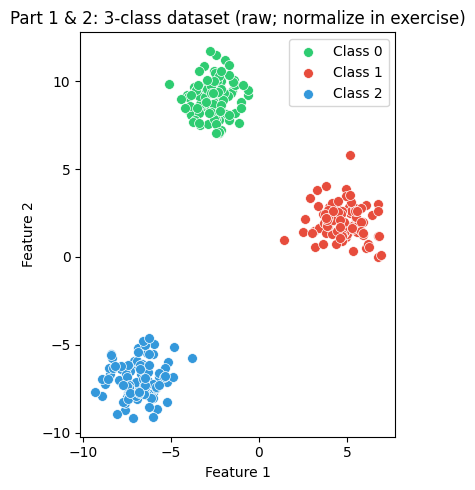

Part 1 & 2 dataset ready: 3 classes, 2 features (raw). Apply min-max normalization in your code.
Variables: X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1, X_ex1, y_ex1
Train: 240 | Test: 60 | Classes: 3


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


# 3-class dataset for Part 1 and Part 2 (generated and split; normalization left for exercise)
from sklearn.datasets import make_blobs

X_ex1_raw, y_ex1 = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)
X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1 = train_test_split(
    X_ex1_raw, y_ex1, test_size=0.2, random_state=42, stratify=y_ex1
)
X_ex1 = np.vstack([X_train_ex1, X_test_ex1])
y_ex1 = np.hstack([y_train_ex1, y_test_ex1])

# Visualize generated dataset (colored by class)
fig, ax = plt.subplots(figsize=(7, 5))
colors_ex1 = ['#2ecc71', '#e74c3c', '#3498db']
for cls in range(3):
    mask = y_ex1 == cls
    ax.scatter(X_ex1[mask, 0], X_ex1[mask, 1], c=colors_ex1[cls], label=f'Class {cls}', s=50, edgecolors='white', linewidths=0.5)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('Part 1 & 2: 3-class dataset (raw; normalize in exercise)')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print("Part 1 & 2 dataset ready: 3 classes, 2 features (raw). Apply min-max normalization in your code.")
print("Variables: X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1, X_ex1, y_ex1")
print("Train:", X_train_ex1.shape[0], "| Test:", X_test_ex1.shape[0], "| Classes:", len(np.unique(y_ex1)))

In [7]:
# Part 1 (50 marks) – Your code here
# Data ready: X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1 (raw)
# 1. Apply min-max normalization (fit on train, transform train and test)
# 2. Use KNN_NumPy (or reimplement) to fit and predict on normalized data
# 3. Compute accuracy
pass  # Replace with your implementation
X_min=X_train_ex1.min(axis=0)
X_max=X_train_ex1.max(axis=0)
X_train_norm=(X_train_ex1-X_min)/(X_max-X_min)
X_test_norm=(X_test_ex1-X_min)/(X_max-X_min)


def knn_predict(X_train, y_train, X_test, k=5):
  predictions=[]

  for x in X_test:
    distances=np.sqrt(np.sum((X_train - x)**2, axis=1))

    k_indices=np.argsort(distances)[:k]
    k_labels=y_train[k_indices]

    values, counts=np.unique(k_labels, return_counts=True)
    prediction=values[np.argmax(counts)]
    predictions.append(prediction)

  return np.array(prediction)
y_pred=knn_predict(X_train_norm, y_train_ex1, X_test_norm, k=5)

accuracy=np.mean(y_pred==y_test_ex1)
print("Accuracy:", accuracy)

Accuracy: 0.3333333333333333


### Part 2 (30 marks) – Same Dataset with Scikit-learn

**Dataset:** Use the same data as Part 1: **X_train_ex1**, **X_test_ex1**, **y_train_ex1**, **y_test_ex1**, and **X_ex1**, **y_ex1** for decision-boundary plots.

**Instructions:**  
- Fit **KNeighborsClassifier** on the same train set and predict on the test set.
- Compare accuracy with your Part 1 NumPy implementation.
- Show **decision boundary** and tune **K** using elbow method or `GridSearchCV`.
- **Write your code in the cell below.**

KNN Accuracy: 1.0


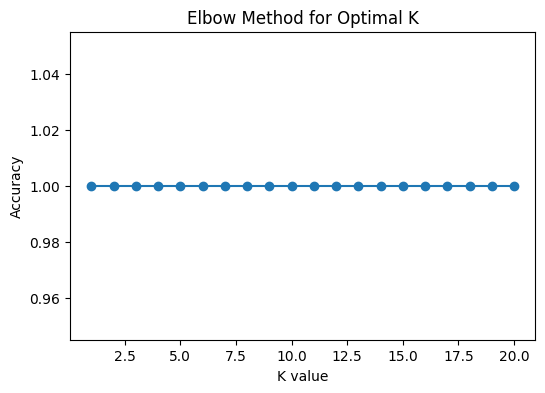

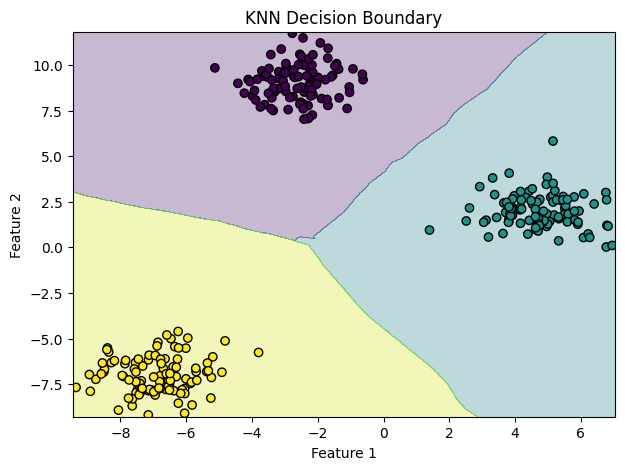

In [10]:
# Part 2 (30 marks) – Your code here
# Data ready: X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1, X_ex1, y_ex1
# 1. Fit KNeighborsClassifier, report accuracy and compare to Part 1
# 2. Plot decision boundary; find best K (elbow or GridSearchCV)
pass  # Replace with your implementation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

X_min=X_train_ex1.min(axis=0)
X_max=X_train_ex1.max(axis=0)

X_train_norm=(X_train_ex1-X_min)/(X_max-X_min)
X_test_norm=(X_test_ex1-X_min)/(X_max-X_min)

knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_norm, y_train_ex1)
y_pred=knn.predict(X_test_norm)
accuracy=accuracy_score(y_test_ex1, y_pred)
print("KNN Accuracy:", accuracy)

k_values=range(1,21)
accuracies=[]

for k in k_values:
  model=KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train_norm, y_train_ex1)
  pred=model.predict(X_test_norm)
  accuracies.append(accuracy_score(y_test_ex1, pred))

plt.figure(figsize=(6,4))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Elbow Method for Optimal K")
plt.show()

h=0.02
x_min, x_max=X_ex1[:,0].min()-0.1, X_ex1[:,0].max()+0.1
y_min, y_max = X_ex1[:,1].min()-0.1, X_ex1[:,1].max()+0.1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_norm = (grid - X_min) / (X_max - X_min)

Z = knn.predict(grid_norm)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_ex1[:,0], X_ex1[:,1], c=y_ex1, edgecolor='k')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("KNN Decision Boundary")

plt.show()






### Dataset for Part 3 (real-world, ready to use)

Run the cell below once. It loads **Breast Cancer**, splits into train/test with stratification, and visualizes it (first two features). Use **X_train_ex3**, **X_test_ex3**, **y_train_ex3**, **y_test_ex3**. **target_names_ex3** and **feature_names_ex3** are available for labels. **X_train_ex3_2d**, **X_test_ex3_2d** are the first two features (for 2D plots). **Normalization (min-max) is left for you to implement in the exercise.**

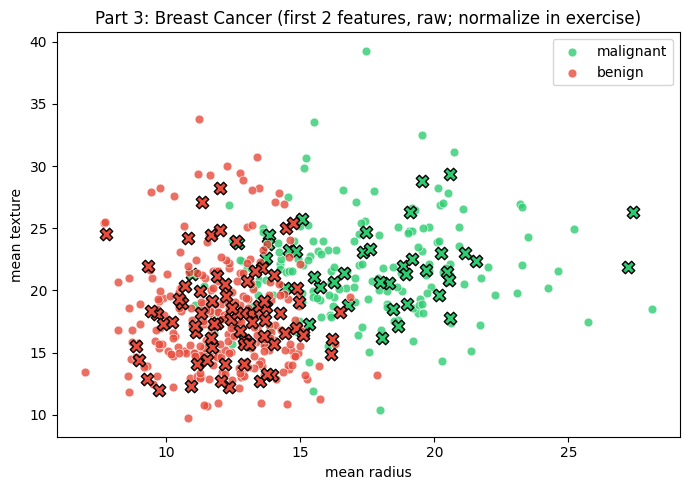

Part 3 dataset ready: Breast Cancer, 30 features (raw). Apply min-max normalization in your code.
Variables: X_train_ex3, X_test_ex3, y_train_ex3, y_test_ex3, X_train_ex3_2d, X_test_ex3_2d
Train: 455 | Test: 114 | Classes: ['malignant', 'benign']


In [8]:
# Real-world dataset for Part 3 (Breast Cancer: loaded and split; normalization left for exercise)
from sklearn.datasets import load_breast_cancer

bc = load_breast_cancer()
X_ex3_raw = bc.data
y_ex3 = bc.target
feature_names_ex3 = np.array(bc.feature_names)
target_names_ex3 = np.array(bc.target_names)

X_train_ex3, X_test_ex3, y_train_ex3, y_test_ex3 = train_test_split(
    X_ex3_raw, y_ex3, test_size=0.2, random_state=42, stratify=y_ex3
)
# First two features for 2D visualization and decision-boundary plots
X_train_ex3_2d = X_train_ex3[:, :2]
X_test_ex3_2d = X_test_ex3[:, :2]

# Visualize generated dataset (first 2 features, colored by class)
fig, ax = plt.subplots(figsize=(7, 5))
colors_ex3 = ['#2ecc71', '#e74c3c']  # benign, malignant
for cls in range(2):
    mask_train = y_train_ex3 == cls
    mask_test = y_test_ex3 == cls
    ax.scatter(X_train_ex3_2d[mask_train, 0], X_train_ex3_2d[mask_train, 1], c=colors_ex3[cls],
              label=target_names_ex3[cls], s=40, alpha=0.8, edgecolors='white', linewidths=0.5)
    ax.scatter(X_test_ex3_2d[mask_test, 0], X_test_ex3_2d[mask_test, 1], c=colors_ex3[cls], s=80, marker='X', edgecolors='black')
ax.set_xlabel(feature_names_ex3[0])
ax.set_ylabel(feature_names_ex3[1])
ax.set_title('Part 3: Breast Cancer (first 2 features, raw; normalize in exercise)')
ax.legend()
plt.tight_layout()
plt.show()

print("Part 3 dataset ready: Breast Cancer, 30 features (raw). Apply min-max normalization in your code.")
print("Variables: X_train_ex3, X_test_ex3, y_train_ex3, y_test_ex3, X_train_ex3_2d, X_test_ex3_2d")
print("Train:", X_train_ex3.shape[0], "| Test:", X_test_ex3.shape[0], "| Classes:", target_names_ex3.tolist())

### Part 3 (20 marks) – Real-World Dataset

**Dataset:** Prepared above: **X_train_ex3**, **X_test_ex3**, **y_train_ex3**, **y_test_ex3** (Breast Cancer, raw). Use **X_train_ex3_2d**, **X_test_ex3_2d** for 2D plots; **target_names_ex3**, **feature_names_ex3** for labels.

**Instructions:**  
- **Apply min-max normalization** (fit on train, transform train and test) before fitting KNN.
- Implement KNN with **sklearn**, find **best K** using elbow or cross-validation.
- Report **accuracy**, **precision**, **recall**, **F1**, **confusion matrix**.
- If possible, show **decision boundary** (use **X_train_ex3_2d** / **X_test_ex3_2d** or PCA).
- **Write your code and short analysis in the cell(s) below.**

Best K: 5
Accuracy: 0.9824561403508771
Precision: 0.972972972972973
Recall: 1.0
F1 Score: 0.9863013698630136
Confusion Matrix:
[[40  2]
 [ 0 72]]


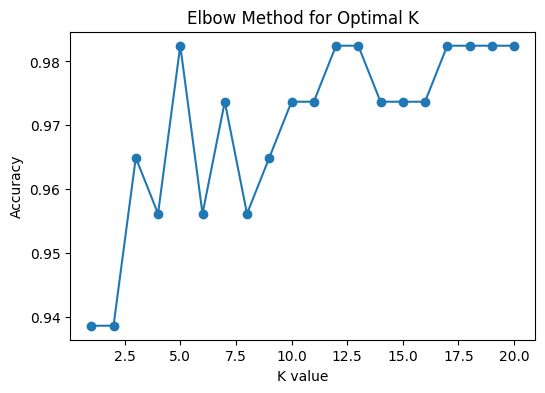

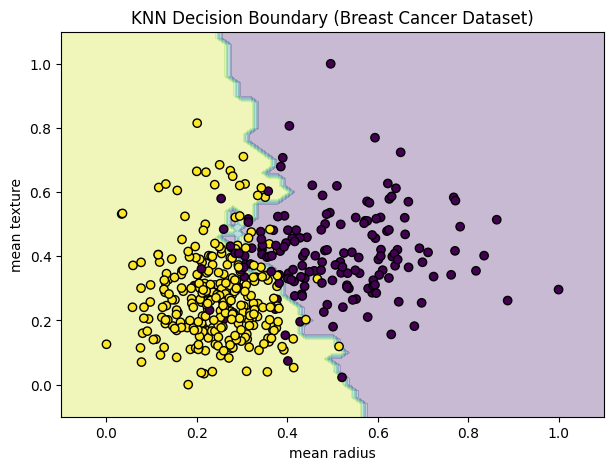

In [11]:
# Part 3 (20 marks) – Your code and analysis here
# Data ready: X_train_ex3, X_test_ex3, y_train_ex3, y_test_ex3, X_train_ex3_2d, X_test_ex3_2d (raw)
# 1. Apply min-max normalization (fit on train, transform train and test)
# 2. Find best K (elbow / GridSearchCV), fit KNN, report accuracy
pass  # Replace with your implementation
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler

# ---- 1. Min-Max Normalization ----
scaler = MinMaxScaler()

X_train_norm = scaler.fit_transform(X_train_ex3)
X_test_norm = scaler.transform(X_test_ex3)

X_train_2d_norm = scaler.fit_transform(X_train_ex3_2d)
X_test_2d_norm = scaler.transform(X_test_ex3_2d)


# ---- 2. Find Best K (Elbow Method) ----
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_norm, y_train_ex3)
    pred = model.predict(X_test_norm)
    accuracies.append(accuracy_score(y_test_ex3, pred))

best_k = k_values[np.argmax(accuracies)]

print("Best K:", best_k)


# ---- 3. Train Final Model ----
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_norm, y_train_ex3)

y_pred = knn.predict(X_test_norm)


# ---- 4. Evaluation Metrics ----
acc = accuracy_score(y_test_ex3, y_pred)
prec = precision_score(y_test_ex3, y_pred)
rec = recall_score(y_test_ex3, y_pred)
f1 = f1_score(y_test_ex3, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

cm = confusion_matrix(y_test_ex3, y_pred)
print("Confusion Matrix:")
print(cm)


# ---- 5. Elbow Plot ----
plt.figure(figsize=(6,4))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("Elbow Method for Optimal K")
plt.show()


# ---- 6. Decision Boundary (2D Features) ----
knn_2d = KNeighborsClassifier(n_neighbors=best_k)
knn_2d.fit(X_train_2d_norm, y_train_ex3)

h = 0.02
x_min, x_max = X_train_2d_norm[:,0].min()-0.1, X_train_2d_norm[:,0].max()+0.1
y_min, y_max = X_train_2d_norm[:,1].min()-0.1, X_train_2d_norm[:,1].max()+0.1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]
Z = knn_2d.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_train_2d_norm[:,0], X_train_2d_norm[:,1], c=y_train_ex3, edgecolor="k")

plt.xlabel(feature_names_ex3[0])
plt.ylabel(feature_names_ex3[1])
plt.title("KNN Decision Boundary (Breast Cancer Dataset)")

plt.show()

---
## 7. Conclusion & Submission

**Key learnings:**  
- KNN is a lazy, distance-based classifier; *k* and the distance metric matter.  
- Implementing KNN from scratch with NumPy (Euclidean distance + majority vote) matches sklearn for the same settings.  
- Scikit-learn provides fast, tunable KNN with options for weights, metric, and algorithm.  
- K can be chosen via the **elbow method** (accuracy vs *k*) or **cross-validation** / **GridSearchCV**.  
- Decision boundaries and accuracy-vs-K plots help interpret and tune the model.
